# Text2Cypher Workflow Demo Notebook

This notebooks demonstrates a text2cypher workflow with visualization capabilities.

## Imports

In [1]:
import nest_asyncio
nest_asyncio.apply()

In [2]:
import asyncio
from IPython.display import Image, display
import os

from neo4j import GraphDatabase
from langchain_neo4j import Neo4jGraph
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

from ps_genai_agents.workflows.multi_agent import create_text2cypher_with_visualization_workflow
from ps_genai_agents.components.state import OutputState
from ps_genai_agents.utils import load_config
from ps_genai_agents.retrievers.cypher_examples import Neo4jVectorSearchCypherExampleRetriever, YAMLCypherExampleRetriever

In [3]:
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
CONFIG = load_config("data/discrete_manufacturing/config.json")

In [5]:
[print(f"{k}: {v}") for k, v in CONFIG.items()]

title: Discrete Manufacturing GenAI
scope_description: This application may answer questions related to Manufacturing Bill of Materials, discrete manufacturing and supply chain management.
cypher_query_yaml_file_path: data/discrete_manufacturing/queries/queries.yml
example_questions: ['What are the most common apple types?', 'What are the suppliers of TLA 86447~6814?', 'What are the suppliers of TLA 86447~6814 and what are all child items of finished good uid 97756?', 'How many suppliers operate outside the US and what are the TLA counts of each country? visualize the result.']


[None, None, None, None]

## Neo4j Graph

This class handles interaction with our Neo4j database. We use `enhanced_schema` to gain more detail about the graph contents.

In [6]:
graph = Neo4jGraph(enhanced_schema=True)

In [7]:
graph.get_structured_schema

{'node_props': {'TLA': [{'property': 'tla_item_uid',
    'type': 'STRING',
    'values': ['97756~37830', '40408~48475', '90615~58107', '86447~6814'],
    'distinct_count': 4},
   {'property': 'bill_sequence_id',
    'type': 'INTEGER',
    'min': '6814',
    'max': '58107',
    'distinct_count': 4},
   {'property': 'item_uid',
    'type': 'STRING',
    'values': ['97756', '40408', '90615', '86447'],
    'distinct_count': 4},
   {'property': 'item_id',
    'type': 'INTEGER',
    'min': '17205',
    'max': '70917',
    'distinct_count': 4},
   {'property': 'organization_id',
    'type': 'INTEGER',
    'min': '200',
    'max': '200',
    'distinct_count': 1},
   {'property': 'organization_code',
    'type': 'STRING',
    'values': ['10141'],
    'distinct_count': 1},
   {'property': 'description',
    'type': 'STRING',
    'values': ['ABC100, 50kW, 60Hz, Standby, Natural Gas/Propane G',
     'ABC345z, 150kW, 60Hz, Standby, Natural Gas/Propane',
     'GeneralDiesel Generator Set, 450kW Stan

## LLM

We will be using an OpenAI LLM for this demo.

In [8]:
llm = ChatOpenAI(model="gpt-4o", temperature=0)

## Cypher Example Retriever

This class is responsible for collecting and formatting Cypher examples for few shot prompting.

## Embedder

In [9]:
embedder = OpenAIEmbeddings(model="text-embedding-ada-002")

## Neo4j Driver

In [10]:
neo4j_driver = GraphDatabase.driver(uri=os.getenv("NEO4J_URI"), auth=(os.getenv("NEO4J_USERNAME"), os.getenv("NEO4J_PASSWORD")))
vector_index_name = "cypher_query_vector_index"

In [11]:
cypher_query_yaml_file_path = CONFIG.get("cypher_query_yaml_file_path", "./")
cypher_example_retriever = Neo4jVectorSearchCypherExampleRetriever(neo4j_driver=neo4j_driver, vector_index_name=vector_index_name, embedder=embedder)
# cypher_example_retriever = YAMLCypherExampleRetriever(cypher_query_yaml_file_path=cypher_query_yaml_file_path)

## Agent

In [12]:
scope_description = CONFIG.get("scope_description", "")


In [13]:
agent = create_text2cypher_with_visualization_workflow(llm=llm, 
                                                       graph=graph, 
                                                       scope_description=scope_description, 
                                                       cypher_example_retriever=cypher_example_retriever, 
                                                       llm_cypher_validation=False, 
                                                       attempt_cypher_execution_on_final_attempt=True)

Here we can see the agent workflow. 
* The workflow always starts at `guardrails` where the input question is determined to be in scope or not.
* The workflow always ends at `final_answer` where the generated contents are formatted to be returned to the user.
* Dotted lines indicate conditional paths.

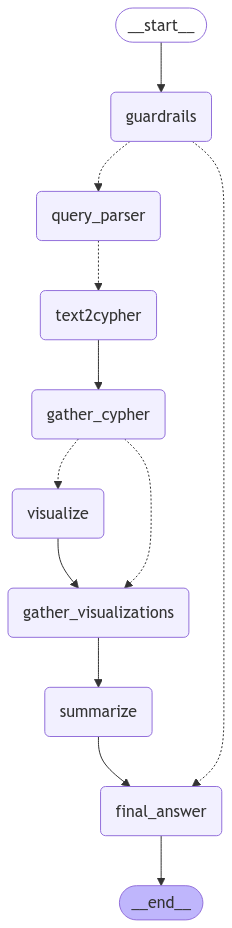

In [14]:
display(Image(agent.get_graph().draw_mermaid_png()))

## Questions

### Helper Functions

In [32]:
async def ask_question(question: str, debug: bool = False) -> OutputState:
    """wrapper to simplify asking questions in the notebook."""

    async def ask():
        response = await agent.ainvoke({"question": question}, debug=debug)
        return response

    return asyncio.run(ask())

def print_answer(response: OutputState) -> None:
    print(response.get("question"))
    print(response.get("answer"))

def print_cypher_queries(response: OutputState) -> None:

   [print(c.get("subquestion") + "\n\n" + c.get("statement")+"\n\n") for c in response.get("cyphers")]

def print_cypher_results(response: OutputState) -> None:

    [(print(c.get("subquestion") + "\n\n"), [print(r) for r in c.get("records")], print("\n\n")) for c in response.get("cyphers")]

def print_viz_results(response: OutputState) -> None:
    [
        (print(v.get("subquestion") + "\n\n" + v.get("chart_description") + "\n\n"), display(v.get("chart"))) for v in response.get("visualizations")
    ]

The agent response is a Python dictionary with the following format:
```python
{
    answer: str,
    question: str,
    steps: List[str],
    cyphers: List[
        subquestion: str,
        statement: str,
        errors: List[str],
        records: List[Dict[str, Any]],
        next_action: str,
        steps: List[str],
    ],
    visualizations: List[
        subquestion: str
        chart: Any
        chart_description: str
        steps: List[str]
    ]
}
```

### 1. Out of Scope

The agent can detect whether a question is in scope and avoid further processing.

In [16]:
q1 = await ask_question("What are the most common apple types?")

In [17]:
print_answer(q1)

What are the most common apple types?
This question is out of scope. Therefore I cannot answer this question.


We can see the agent only performs 2 steps - only `guardrails` requires an LLM call.

In [18]:
q1.get("steps")

['guardrails', 'final_answer']

### 2. Cypher Question without Visualization

The agent is capable of creating Cypher queries to answer questions within the scope of the data.

In [19]:
q2 = await ask_question("What are the suppliers of TLA 86447~6814?", debug=False)

In [20]:
print_answer(q2)

What are the suppliers of TLA 86447~6814?
- Supplier-20 (DECATUR-00, US)
- Supplier-57 (10001, US)
- Supplier-15 (STOUGHTON-00, US)
- Supplier-55 (AHMEDNAGAR-00, IN)
- Supplier-55 (10031, IN)
- Supplier-55 (RANJANGAON-00, IN)
- Supplier-55 (WUXI-01, CN)
- Supplier-113 (SAINT PAUL-00, US)
- Supplier-148 (10001, US)
- Supplier-165 (10001, US)
- Supplier-162 (MINNEAPOLIS-00, US)


All Cypher queries are saved for evaluation.

In [21]:
print_cypher_queries(q2)

Who are the suppliers of TLA 86447~6814?

MATCH (:TLA {tla_item_uid: "86447~6814"})-[:HAS_CHILD]->(i:Item)-[:HAS_SUPPLIER]->(s:Supplier)
RETURN DISTINCT s.supplier_name, s.vendor_site_code, s.country




Results are saved as well for evaluation or futher processing.

In [22]:
print_cypher_results(q2)

Who are the suppliers of TLA 86447~6814?


{'s.supplier_name': 'Supplier-20', 's.vendor_site_code': 'DECATUR-00', 's.country': 'US'}
{'s.supplier_name': 'Supplier-57', 's.vendor_site_code': '10001', 's.country': 'US'}
{'s.supplier_name': 'Supplier-15', 's.vendor_site_code': 'STOUGHTON-00', 's.country': 'US'}
{'s.supplier_name': 'Supplier-55', 's.vendor_site_code': 'AHMEDNAGAR-00', 's.country': 'IN'}
{'s.supplier_name': 'Supplier-55', 's.vendor_site_code': '10031', 's.country': 'IN'}
{'s.supplier_name': 'Supplier-55', 's.vendor_site_code': 'RANJANGAON-00', 's.country': 'IN'}
{'s.supplier_name': 'Supplier-55', 's.vendor_site_code': 'WUXI-01', 's.country': 'CN'}
{'s.supplier_name': 'Supplier-113', 's.vendor_site_code': 'SAINT PAUL-00', 's.country': 'US'}
{'s.supplier_name': 'Supplier-148', 's.vendor_site_code': '10001', 's.country': 'US'}
{'s.supplier_name': 'Supplier-165', 's.vendor_site_code': '10001', 's.country': 'US'}
{'s.supplier_name': 'Supplier-162', 's.vendor_site_code': 'MINNEAP

### 3. Multi-Cypher Query Question without Visualization

The agent is capable of splitting the input question into multiple subquestions. These will be individually addressed with their own Cypher queries. 
The final answer will summarize the query results together.

In [38]:
q3 = await ask_question("What are the suppliers of TLA 86447~6814 and what are all child items of finished good uid 97756?", debug=False)

In [39]:
print_answer(q3)

What are the suppliers of TLA 86447~6814 and what are all child items of finished good uid 97756?
**Suppliers of TLA 86447~6814:**

- Supplier-20 (Vendor Site Code: DECATUR-00, Country: US)
- Supplier-57 (Vendor Site Code: 10001, Country: US)
- Supplier-15 (Vendor Site Code: STOUGHTON-00, Country: US)
- Supplier-55 (Vendor Site Code: AHMEDNAGAR-00, Country: IN)
- Supplier-55 (Vendor Site Code: 10031, Country: IN)
- Supplier-55 (Vendor Site Code: RANJANGAON-00, Country: IN)
- Supplier-55 (Vendor Site Code: WUXI-01, Country: CN)
- Supplier-113 (Vendor Site Code: SAINT PAUL-00, Country: US)
- Supplier-148 (Vendor Site Code: 10001, Country: US)
- Supplier-165 (Vendor Site Code: 10001, Country: US)
- Supplier-162 (Vendor Site Code: MINNEAPOLIS-00, Country: US)

**Child items of finished good UID 97756:**

- Item UID: 42409, Description: ANTIFREEZE
- Item UID: 62611, Description: SILENCER,EXHAUST
- Item UID: 93626, Description: GENERATOR
- Item UID: 52754, Description: LIST,LITERATURE
- Item

In [40]:
print_cypher_queries(q3)

What are the suppliers of TLA 86447~6814?

MATCH (:TLA {tla_item_uid: "86447~6814"})-[:HAS_CHILD]->(i:Item)-[:HAS_SUPPLIER]->(s:Supplier)
RETURN DISTINCT s.supplier_name, s.vendor_site_code, s.country


What are all child items of finished good UID 97756?

MATCH (:FinishedGood {item_uid: "97756"})-[:HAS_CHILD]->(i:Item)
RETURN i.item_uid, i.description, i.item_id, i.organization_code, i.UOM_code, i.maximum_order_quantity, i.planning_make_buy_code_description




### 4. Question with Visualization

If visualization is requested, the agent will attempt to create either a bar, line or scatter plot to fit the results gathered from Neo4j.

/var/folders/7_/vqs74z3j5hscgzbt0ydbmqyw0000gq/T/ipykernel_55190/1953630900.py:1: RuntimeWarning: coroutine 'ask_question' was never awaited
  q4 = await ask_question("How many suppliers operate outside the US and what are the TLA counts of each country? visualize the result.", debug=False)


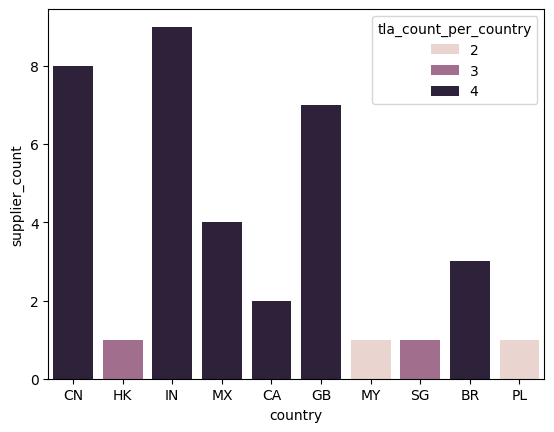

In [27]:
q4 = await ask_question("How many suppliers operate outside the US and what are the TLA counts of each country? visualize the result.", debug=False)

We recieve a description along with each generated chart.

How many suppliers operate outside the US and what are the TLA counts of each country?

This chart displays the number of suppliers operating outside the US for each country. The countries are represented on the x-axis, the number of suppliers on the y-axis, and the TLA (Three-Letter Acronym) counts are used to differentiate the bars by color.




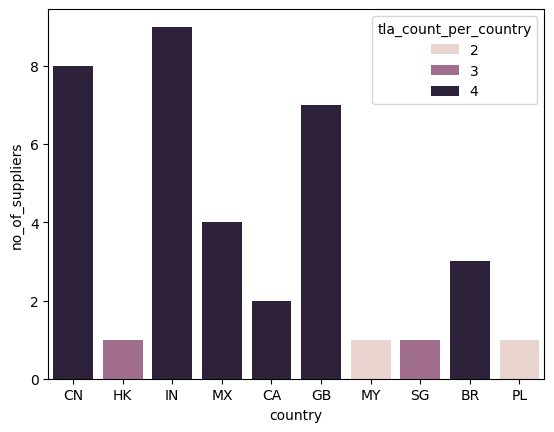

In [32]:
print_viz_results(q4)

We still recieve everything else in the result such as the summary and Cypher info.

In [28]:
print_answer(q4)

How many suppliers operate outside the US and what are the TLA counts of each country? visualize the result.
- **China (CN):** 8 suppliers, TLA count: 4
- **Hong Kong (HK):** 1 supplier, TLA count: 3
- **India (IN):** 9 suppliers, TLA count: 4
- **Mexico (MX):** 4 suppliers, TLA count: 4
- **Canada (CA):** 2 suppliers, TLA count: 4
- **United Kingdom (GB):** 7 suppliers, TLA count: 4
- **Malaysia (MY):** 1 supplier, TLA count: 2
- **Singapore (SG):** 1 supplier, TLA count: 3
- **Brazil (BR):** 3 suppliers, TLA count: 4
- **Poland (PL):** 1 supplier, TLA count: 2


In [29]:
print_cypher_queries(q4)

How many suppliers operate outside the US and what are the TLA counts of each country?

MATCH (s:Supplier)<-[:HAS_SUPPLIER]-(i)<-[r:HAS_CHILD]-()
WHERE s.country <> "US"
WITH s.country AS country, count(distinct s) AS supplier_count, collect(distinct r.tla_uid) AS tla_uids
RETURN country, supplier_count, size(tla_uids) AS tla_count_per_country;


